# Week 3 Day 4 Lab

### Problem 1
We are going to make a social network. This can be real or made up. Up to you!
1. Add nodes representing people
2. Add edges if these people talk
3. Make the edges bigger if they are good friends and smaller if they are just acquaintances
4. Make the nodes size correspond to height
5. Make the node color correspond to hair color (i.e. if hair is brunette, the node is brown)


Make sure your final plot has:
- a title
- the names of the people displayed
- color
- is legible and presentable
- an appropriate sizing

(np.float64(-0.6692752967974824),
 np.float64(0.5671726907053167),
 np.float64(-1.195156214101829),
 np.float64(1.0537868245954398))

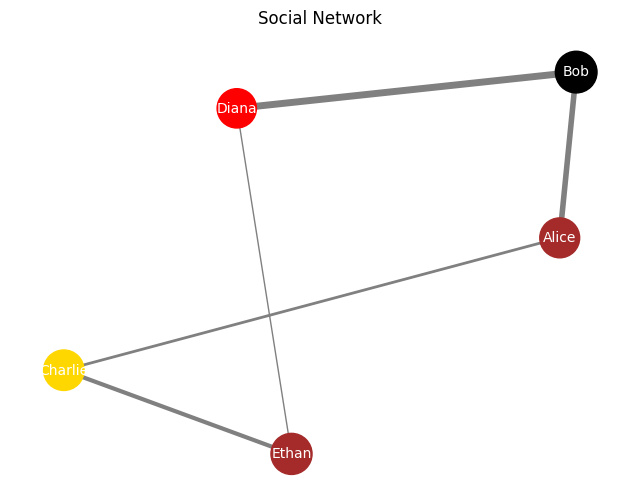

In [5]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

G.add_node("Alice", height=165, hair="brown")
G.add_node("Bob", height=180, hair="black")
G.add_node("Charlie", height=170, hair="blonde")
G.add_node("Diana", height=160, hair="red")
G.add_node("Ethan", height=175, hair="brown")

G.add_edge("Alice", "Bob", weight=4)
G.add_edge("Alice", "Charlie", weight=2)
G.add_edge("Bob", "Diana", weight=5)
G.add_edge("Charlie", "Ethan", weight=3)
G.add_edge("Diana", "Ethan", weight=1)

node_sizes = [G.nodes[node]["height"] * 5 for node in G.nodes]

hair_colors = {
    "brown": "brown",
    "black": "black",
    "blonde": "gold",
    "red": "red"
}
node_colors = [hair_colors[G.nodes[node]["hair"]] for node in G.nodes]

edge_widths = [G[u][v]["weight"] for u, v in G.edges]

pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes,
    node_color=node_colors
)
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color="gray"
)
nx.draw_networkx_labels(
    G, pos,
    font_size=10,
    font_color="white"
)

plt.title("Social Network")
plt.axis("off")

### Problem 2

For the dolphin social network:
1. Import the data
2. Draw the network 
3. Use as many `networkx` parameters as possible (that is, in `nx.draw()`, add all the parameters: `node_size`, `node_color`, etc.) such that the network is still presentable and understandable

You can find some information about `nx.draw()` here: https://networkx.org/documentation/stable/reference/generated/networkx.drawing.nx_pylab.draw.html#networkx.drawing.nx_pylab.draw .


(np.float64(-0.615440283001093),
 np.float64(0.5870488348693539),
 np.float64(-1.168139353221581),
 np.float64(0.7694665267604459))

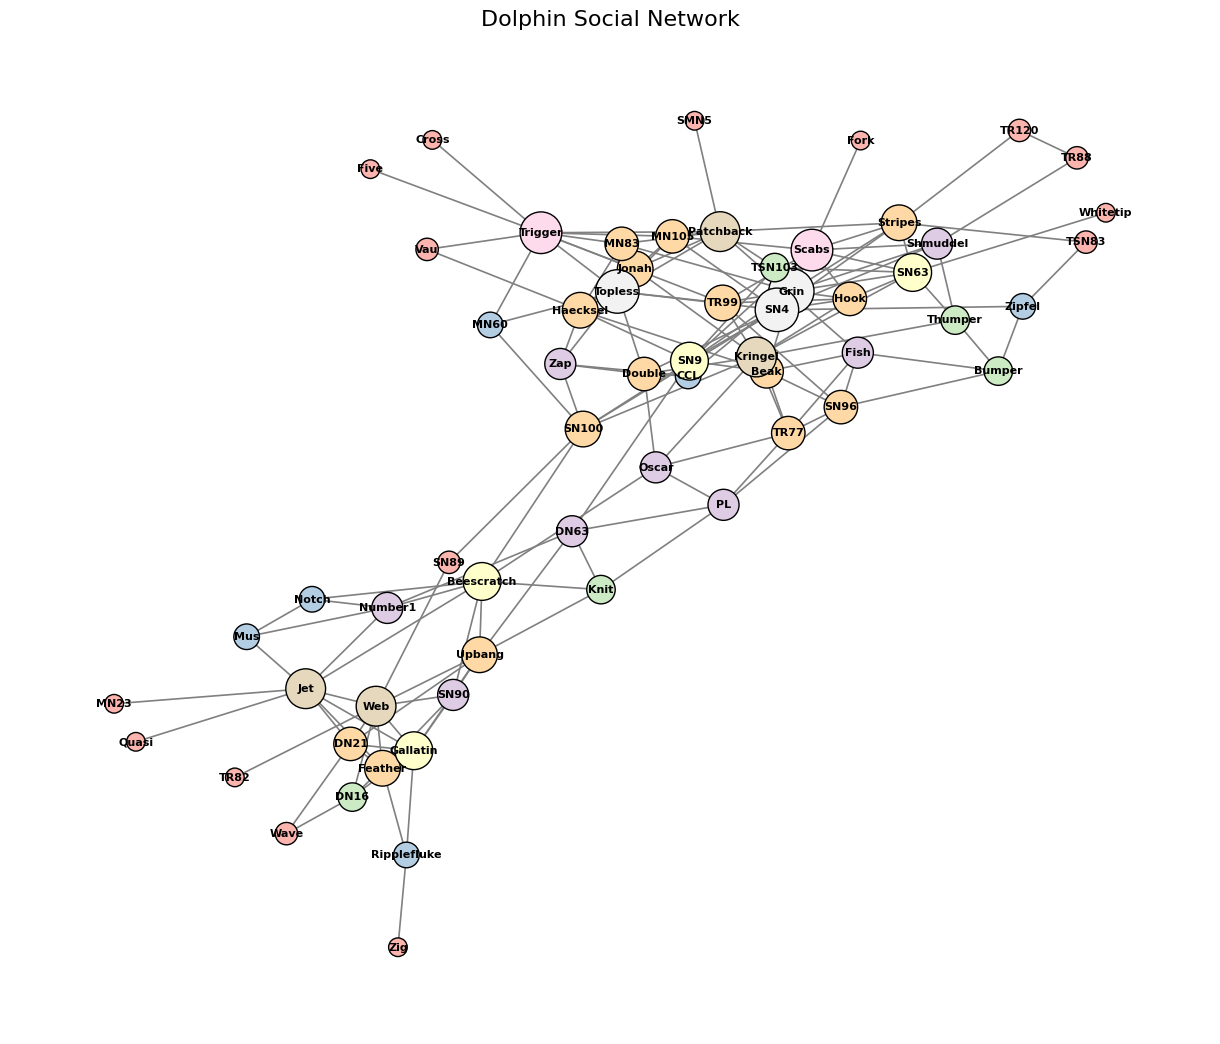

In [19]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv("DolphinNetwork.csv")

G = nx.from_pandas_edgelist(df, source=df.columns[0], target=df.columns[1])

degrees = dict(G.degree())

node_sizes = [100 + 80 * degrees[node] for node in G.nodes()]

node_colors = [degrees[node] for node in G.nodes()]

edge_widths = [1.2 for _ in G.edges()]

pos = nx.spring_layout(G)

plt.figure(figsize=(12, 10))

nx.draw(
    G,
    pos=pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Pastel1,
    edge_color="gray",
    width=edge_widths,
    style="solid",
    edgecolors="black",
    font_size=8,
    font_color="black",
    font_weight="bold",
    font_family="sans-serif",
    arrows=False
)

plt.title("Dolphin Social Network", fontsize=16)
plt.axis("off")
